### Instalação das Dependências

In [ ]:
%pip install numpy matplotlib

### Importação das Bibliotecas

In [4]:
import numpy as np
import matplotlib.pyplot as plt

### Carregamento dos dados do CSV

In [13]:
try:
    # Delimitador é vírgula e pula a primeira linha (cabeçalho) com skiprows = 1
    dados = np.loadtxt('dataset.csv', delimiter=',', skiprows=1)
except FileNotFoundError:
    print("Erro: Arquivo 'dataset.csv' não encontrado.")
    print("Por favor, crie o arquivo ou execute o script para gerá-lo.")
    exit()

# Apenas visualizando os dados carregados do arquivo CSV.
print(dados)

[[ 50. 150.]
 [ 60. 200.]
 [ 70. 250.]
 [ 80. 300.]
 [ 90. 350.]
 [100. 400.]
 [110. 420.]
 [120. 450.]
 [130. 470.]
 [140. 500.]]


### Separando os dados de X e Y

In [14]:
X = dados[:, 0]
y = dados[:, 1]
n = len(X)

# Visualiza os dados
print("X:", X)
print("y:", y)

print("\n Número de amostras: ", X.shape[0])

X: [ 50.  60.  70.  80.  90. 100. 110. 120. 130. 140.]
y: [150. 200. 250. 300. 350. 400. 420. 450. 470. 500.]

 Número de amostras:  10


### Restruturando os dados

In [23]:
X = X.reshape(-1, 1)
y = y.reshape(-1, 1)

print("x (reshaped):\n", X)
print("y (reshaped):\n", y)

x (reshaped):
 [[ 50.]
 [ 60.]
 [ 70.]
 [ 80.]
 [ 90.]
 [100.]
 [110.]
 [120.]
 [130.]
 [140.]]
y (reshaped):
 [[150.]
 [200.]
 [250.]
 [300.]
 [350.]
 [400.]
 [420.]
 [450.]
 [470.]
 [500.]]


In [26]:
print("Número de características:", X.shape[1])
print("Número de Saídas:", y.shape[1])
print("Número total de elementos em X:", X.size)
print("Número total de elementos em y:", y.size)
print("Tipo de dados em X:", X.dtype)
print("Tipo de dados em y:", y.dtype)
print("Tamanho em bytes de cada elemento da X:", X.itemsize) 
print("Tamanho em bytes de cada elemento da y:", y.itemsize)
print("Número total de bytes consumidos por X:", X.nbytes)
print("Número total de bytes consumidos por y:", y.nbytes)
print("Número de dimensões de X:", X.ndim)
print("Número de dimensões de y:", y.ndim)

Número de características: 1
Número de Saídas: 1
Número total de elementos em X: 10
Número total de elementos em y: 10
Tipo de dados em X: float64
Tipo de dados em y: float64
Tamanho em bytes de cada elemento da X: 8
Tamanho em bytes de cada elemento da y: 8
Número total de bytes consumidos por X: 80
Número total de bytes consumidos por y: 80
Número de dimensões de X: 2
Número de dimensões de y: 2


Média de X: 95.0
Média de y: 349.0

Intercepto (a): -22.3636
Inclinação (b): 3.9091

Valores previstos: [173.09090909 212.18181818 251.27272727 290.36363636 329.45454545
 368.54545455 407.63636364 446.72727273 485.81818182 524.90909091]

Cálculo do Coeficiente de Pearson: 0.9875

Cálculo de Determinação: 97.5081


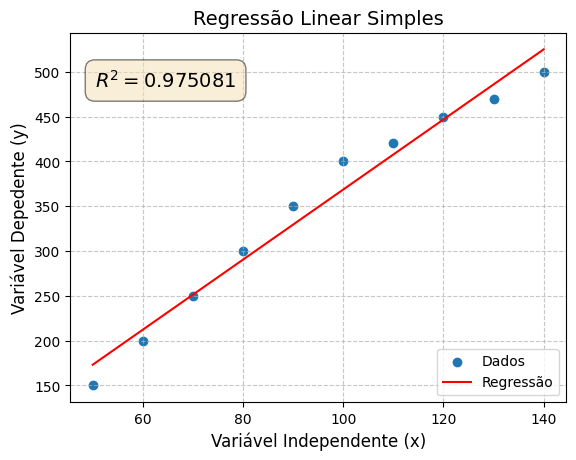

In [10]:
# 1. Calcular os coeficientes da regressão linear (a e b)
x_mean = np.mean(X)
y_mean = np.mean(y)

print("Média de X:", x_mean)
print("Média de y:", y_mean)

b, a = np.polyfit(X, y, 1)
print(f"\nIntercepto (a): {a:.4f}")
print(f"Inclinação (b): {b:.4f}")

y_pred = a + b * X
print(f"\nValores previstos: {y_pred}")

# Cálculo do Coeficiente de Correlação de Pearson (r)
coef_pearson = np.corrcoef(X, y)[0, 1]
print(f"\nCálculo do Coeficiente de Pearson: {coef_pearson:.4f}")

# Cálculo do Coeficiente de Determinação (r²)
det_quadrado = coef_pearson ** 2
print(f"\nCálculo de Determinação: {det_quadrado * 100:.4f}")

plt.scatter(X, y, label="Dados")
plt.plot(X, y_pred, color="red", label="Regressão")
plt.title("Regressão Linear Simples", fontsize=14)
plt.xlabel("Variável Independente (x)", fontsize=12)
plt.ylabel("Variável Depedente (y)", fontsize=12)
# Adiciona o valor de R² ao gráfico para fácil visualização
plt.text(0.05, 0.9, f'$R^2 = {det_quadrado:4f}$', transform=plt.gca().transAxes, fontsize=14, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


Somatório de X:  950.0
Somatório de Y:  3490.0

Intercepto (a): -22.363636363636353
Inclinação (b): 3.909090909090909

Valores previstos: 
[[173.09090909]
 [212.18181818]
 [251.27272727]
 [290.36363636]
 [329.45454545]
 [368.54545455]
 [407.63636364]
 [446.72727273]
 [485.81818182]
 [524.90909091]]

Equação da Reta: ŷ = -22.3636 + 3.9091 * x
Coeficiente de Correlação (r): = 0.9875
Coeficiente de Determinação (r²): = 0.9751


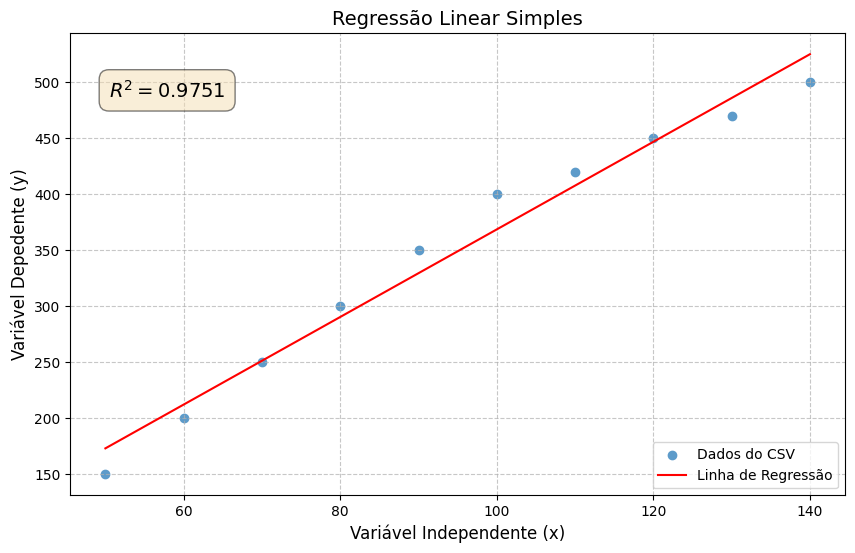

In [28]:
# 2. Cálculo dos somatórios necessários para as fórmulas
sum_x = np.sum(X)
sum_y = np.sum(y)
sum_xy = np.sum(X * y)
sum_x2 = np.sum(X ** 2)
sum_y2 = np.sum(y ** 2)
print("Somatório de X: ", sum_x)
print("Somatório de Y: ", sum_y)

# 3. Cálculo da Reta de Regressão (y_hat = a + b * x)
# Calculando o coeficiente 'b'
b = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - sum_x**2)
# Calculando coeficiente 'a'
a = (sum_y - b * sum_x) / n
print("\nIntercepto (a):", a)
print("Inclinação (b):", b)

# Gerando os valores previstos (y_pred)
y_pred = a + b * X
print(f"\nValores previstos: \n{y_pred}")

# 4. Cálculo do Coeficiente de Correlação de Pearson (r)
numerador_r = n * sum_xy - (sum_x * sum_y)
denominador_r = np.sqrt(n * sum_x2 - sum_x**2) * np.sqrt(n * sum_y2 - sum_y ** 2)
r = numerador_r / denominador_r

# 5. Cálculo do Coeficiente de Determinação (R²)
y_mean = np.mean(y)
# Fórmula : Somatória de (y_hat - y_mean)² divido pelo Somatório de (y - y_mean)²
sq_reg = np.sum((y_pred - y_mean) ** 2)
sq_tot = np.sum((y-y_mean) ** 2)
r2 = sq_reg / sq_tot

# 6. Exibição dos Resultados no Console
print(f"\nEquação da Reta: ŷ = {a:.4f} + {b:.4f} * x")
print(f"Coeficiente de Correlação (r): = {r:.4f}")
print(f"Coeficiente de Determinação (r²): = {r2:.4f}")

# 7. Visualização Gráfica dos Dados
plt.figure(figsize=(10,6))

# Gráfico de dispersão (Scatter plot) dos dados reais
plt.scatter(X, y, color='#5D9BCA', label='Dados do CSV')

# Linha de regressão gerada pelo modelo
plt.plot(X, y_pred, color='red', label="Linha de Regressão")

# Configurações de layout do gráfico
plt.title("Regressão Linear Simples", fontsize=14)
plt.xlabel("Variável Independente (x)", fontsize=12)
plt.ylabel("Variável Depedente (y)", fontsize=12)

# Adiciona o valor de R² ao gráfico para fácil visualização
plt.text(
    0.05, 0.9,
    f'$R^2 = {r2:.4f}$',
    transform=plt.gca().transAxes,
    fontsize=14,
    verticalalignment='top',
    bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5)
)

plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

